# DNS Record Analysis

Investigates `text/dns` records across all 15 target domains.

**Context:** DNS record capture (`mime=text/dns`) was introduced in the 2024 EOT crawl — earlier crawls (2004–2020) were not configured to log DNS lookups as separate WARC records. All 25,822 DNS records in the dataset are from 2024. This is a crawler configuration choice (Heritrix), not something the government agencies control.

**Key question:** why does ed.gov account for ~94% of all 2024 DNS records (~24k vs <100 for every other domain)?

Sections:
1. DNS records per domain
2. DNS records vs total captures — ratio analysis
3. ed.gov deep dive

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from config import TARGET_DOMAINS, DATA_DIR
from split_domains import domain_folder_name

sns.set_theme(style='whitegrid')

DOMAINS_DIR = Path('..') / DATA_DIR / 'domains'

def db_path(domain: str) -> Path:
    folder = domain_folder_name(domain, TARGET_DOMAINS)
    return DOMAINS_DIR / folder / 'cdxj.duckdb'

missing = [d for d in TARGET_DOMAINS if not db_path(d).exists()]
print(f'{len(TARGET_DOMAINS) - len(missing)}/{len(TARGET_DOMAINS)} domain DBs found')
if missing:
    print('Missing:', missing)

15/15 domain DBs found


## 1. DNS Records per Domain (2024 crawl only)

In [2]:
rows = []
for domain in TARGET_DOMAINS:
    p = db_path(domain)
    if not p.exists():
        continue
    con = duckdb.connect(str(p), read_only=True)
    dns_n   = con.sql("SELECT COUNT(*) FROM eot_captures WHERE mime = 'text/dns'").fetchone()[0]
    total_n = con.sql("SELECT COUNT(*) FROM eot_captures").fetchone()[0]
    con.close()
    rows.append({'domain': domain, 'dns_records': dns_n, 'total_records': total_n})

df = pd.DataFrame(rows).sort_values('dns_records', ascending=False)
df['dns_pct'] = (100 * df['dns_records'] / df['total_records']).round(4)
df

,domain,dns_records,total_records,dns_pct
3,ed.gov,24407,47374326,0.0515
7,hud.gov,367,7305116,0.0050
2,defense.gov,338,4172427,0.0081
0,usda.gov,222,144257941,0.0002
14,va.gov,126,12572578,0.0010
5,hhs.gov,95,18878987,0.0005
11,state.gov,77,11654570,0.0007
9,justice.gov,58,4083203,0.0014
10,dol.gov,42,3609960,0.0012
4,energy.gov,28,21730112,0.0001


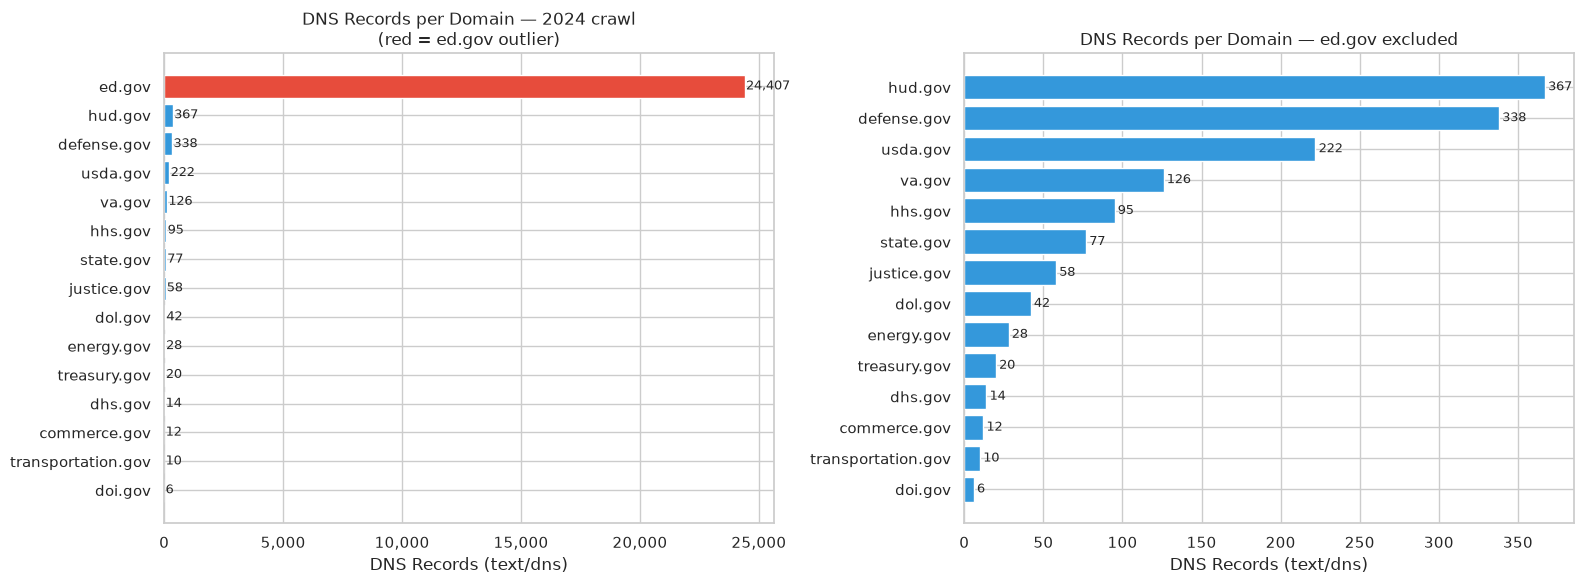

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all domains
ax = axes[0]
colors = ['#e74c3c' if d == 'ed.gov' else '#3498db' for d in df['domain']]
ax.barh(df['domain'][::-1], df['dns_records'][::-1], color=colors[::-1])
for bar in ax.patches:
    w = bar.get_width()
    if w > 0:
        ax.text(w + 50, bar.get_y() + bar.get_height() / 2,
                f'{w:,}', va='center', fontsize=9)
ax.set_xlabel('DNS Records (text/dns)')
ax.set_title('DNS Records per Domain — 2024 crawl\n(red = ed.gov outlier)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Right: ed.gov excluded
ax2 = axes[1]
df_no_ed = df[df['domain'] != 'ed.gov'].sort_values('dns_records', ascending=False)
ax2.barh(df_no_ed['domain'][::-1], df_no_ed['dns_records'][::-1], color='#3498db')
for bar in ax2.patches:
    w = bar.get_width()
    if w > 0:
        ax2.text(w + 2, bar.get_y() + bar.get_height() / 2,
                 f'{w:,}', va='center', fontsize=9)
ax2.set_xlabel('DNS Records (text/dns)')
ax2.set_title('DNS Records per Domain — ed.gov excluded')

plt.tight_layout()
plt.show()

## 2. DNS Records vs Total Captures — Ratio Analysis

Is ed.gov's DNS count high relative to its total crawl size, or is it just a large domain?

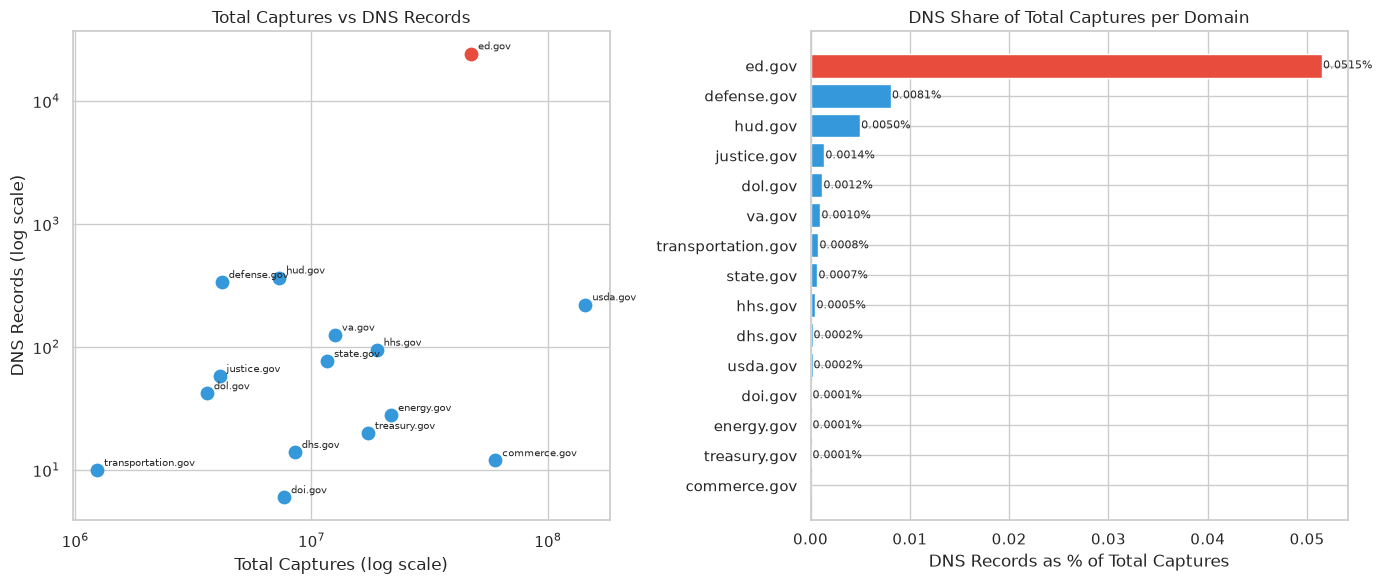


Summary table:
            domain  dns_records  total_records  dns_pct
            ed.gov        24407       47374326   0.0515
       defense.gov          338        4172427   0.0081
           hud.gov          367        7305116   0.0050
       justice.gov           58        4083203   0.0014
           dol.gov           42        3609960   0.0012
            va.gov          126       12572578   0.0010
transportation.gov           10        1239292   0.0008
         state.gov           77       11654570   0.0007
           hhs.gov           95       18878987   0.0005
          usda.gov          222      144257941   0.0002
           dhs.gov           14        8501061   0.0002
      treasury.gov           20       17342038   0.0001
        energy.gov           28       21730112   0.0001
           doi.gov            6        7658404   0.0001
      commerce.gov           12       59967307   0.0000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter — total captures vs DNS records (log scale)
ax = axes[0]
for _, row in df.iterrows():
    color = '#e74c3c' if row['domain'] == 'ed.gov' else '#3498db'
    ax.scatter(row['total_records'], row['dns_records'], color=color, s=80, zorder=3)
    ax.annotate(row['domain'], (row['total_records'], row['dns_records']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total Captures (log scale)')
ax.set_ylabel('DNS Records (log scale)')
ax.set_title('Total Captures vs DNS Records')

# Right: DNS as % of total captures
ax2 = axes[1]
df_pct = df.sort_values('dns_pct', ascending=True)
colors2 = ['#e74c3c' if d == 'ed.gov' else '#3498db' for d in df_pct['domain']]
ax2.barh(df_pct['domain'], df_pct['dns_pct'], color=colors2)
for bar in ax2.patches:
    w = bar.get_width()
    if w > 0:
        ax2.text(w + 0.0001, bar.get_y() + bar.get_height() / 2,
                 f'{w:.4f}%', va='center', fontsize=8)
ax2.set_xlabel('DNS Records as % of Total Captures')
ax2.set_title('DNS Share of Total Captures per Domain')

plt.tight_layout()
plt.show()

print('\nSummary table:')
print(df[['domain','dns_records','total_records','dns_pct']].sort_values('dns_pct', ascending=False).to_string(index=False))

## 3. ed.gov Deep Dive

What are these DNS records? Is it a small set of hosts hit repeatedly, or a huge number of unique subdomains?
The answer points toward different explanations (crawler retry loop vs. genuinely large subdomain footprint).

In [5]:
ed_con = duckdb.connect(str(db_path('ed.gov')), read_only=True)

# Sample DNS rows
ed_con.sql("""
    SELECT url, host, fetch_timestamp, status, "length"
    FROM eot_captures
    WHERE mime = 'text/dns'
    ORDER BY fetch_timestamp
    LIMIT 20
""").df()

,url,host,fetch_timestamp,status,length
0,dns:nces.ed.gov?TYPE=A,nces.ed.gov,20250221001928,<NA>,447
1,dns:nces.ed.gov?TYPE=AAAA,nces.ed.gov,20250221001928,<NA>,489
2,dns:www2.ed.gov?TYPE=A,www2.ed.gov,20250221020809,<NA>,470
3,dns:www2.ed.gov?TYPE=AAAA,www2.ed.gov,20250221020809,<NA>,476
4,dns:www.ed.gov?TYPE=A,www.ed.gov,20250221020811,<NA>,469
5,dns:www.ed.gov?TYPE=AAAA,www.ed.gov,20250221020811,<NA>,477
6,dns:studentaid.ed.gov?TYPE=A,studentaid.ed.gov,20250221023655,<NA>,453
7,dns:studentaid.ed.gov?TYPE=A,studentaid.ed.gov,20250221023655,<NA>,456
8,dns:studentaid.ed.gov?TYPE=AAAA,studentaid.ed.gov,20250221023655,<NA>,458
9,dns:studentaid.ed.gov?TYPE=AAAA,studentaid.ed.gov,20250221023655,<NA>,459


In [6]:
# Unique hosts vs total DNS records — key diagnostic
ed_con.sql("""
    SELECT
        COUNT(*)              AS total_dns_records,
        COUNT(DISTINCT url)   AS unique_dns_urls,
        COUNT(DISTINCT host)  AS unique_hosts
    FROM eot_captures
    WHERE mime = 'text/dns'
""").df()

,total_dns_records,unique_dns_urls,unique_hosts
0,24407,536,268


In [7]:
# Most common hosts — are a few hosts dominating, or is it spread across many?
top_hosts = ed_con.sql("""
    SELECT host, COUNT(*) AS n
    FROM eot_captures
    WHERE mime = 'text/dns'
    GROUP BY host
    ORDER BY n DESC
    LIMIT 30
""").df()
top_hosts

,host,n
0,www.ifap.ed.gov,6331
1,studentaid.ed.gov,3462
2,preview.www2.ed.gov,1483
3,mbk.ed.gov,1362
4,www.rsa.ed.gov,1235
5,tech.ed.gov,646
6,fsaregistration.ed.gov,479
7,preview.ed.gov,394
8,ies.ed.gov,370
9,www.fafsa.ed.gov,324


In [8]:
# Distribution: how many hosts appear exactly once vs multiple times?
ed_con.sql("""
    WITH host_counts AS (
        SELECT host, COUNT(*) AS n
        FROM eot_captures
        WHERE mime = 'text/dns'
        GROUP BY host
    )
    SELECT
        CASE
            WHEN n = 1  THEN '1 (seen once)'
            WHEN n <= 5 THEN '2-5'
            WHEN n <= 20 THEN '6-20'
            ELSE '20+'
        END AS occurrences_per_host,
        COUNT(*) AS host_count,
        SUM(n)   AS total_dns_records
    FROM host_counts
    GROUP BY 1
    ORDER BY MIN(n)
""").df()

,occurrences_per_host,host_count,total_dns_records
0,2-5,89,228.0
1,6-20,74,876.0
2,20+,105,23303.0


In [9]:
ed_con.close()